# Lead Scoring Case Study  
## Predicting Lead Conversion using Logistic Regression  

## Submitted by: Priyanka  

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\UpGrad\\Leads.csv")

In [3]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [5]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [6]:
df.columns

Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

## Data Cleaning

**1. Remove useless columns**

In [7]:
df.drop(columns=[col for col in ['Prospect ID', 'Lead Number'] if col in df.columns], inplace=True)

**2. Replace 'Select' → NaN**

In [8]:
df = df.replace('Select', pd.NA)

**3. Handle Missing Value**

In [11]:
df.isnull().sum()


Lead Origin                                      0
Lead Source                                      0
Do Not Email                                     0
Do Not Call                                      0
Converted                                        0
TotalVisits                                      0
Total Time Spent on Website                      0
Page Views Per Visit                             0
Last Activity                                    0
Country                                          0
Specialization                                   0
How did you hear about X Education               0
What is your current occupation                  0
What matters most to you in choosing a course    0
Search                                           0
Magazine                                         0
Newspaper Article                                0
X Education Forums                               0
Newspaper                                        0
Digital Advertisement          

In [12]:
# Handling missing values properly

# Numeric columns → median
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

**4. Drop duplicates**

In [13]:
df.drop_duplicates(inplace=True)

# EDA (Exploratory Data Analysis)

**1. Target variable check**

In [14]:
df['Converted'].value_counts(normalize=True)

Converted
0    0.602491
1    0.397509
Name: proportion, dtype: float64

**2. Graphs**

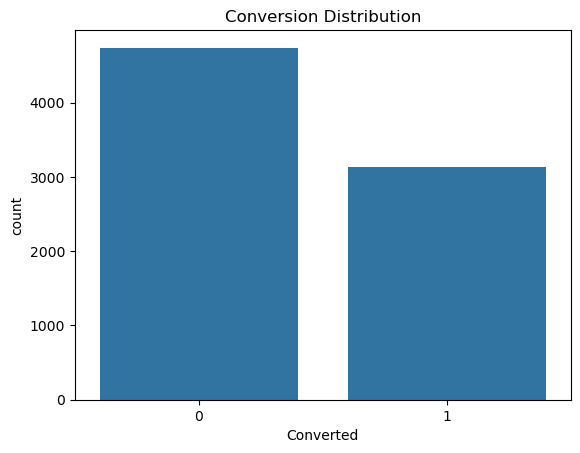

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Converted', data=df)
plt.title("Conversion Distribution")
plt.show()

**3. Important relationships**

**Numerical Features Analysis**

**(A) Total Time Spent**

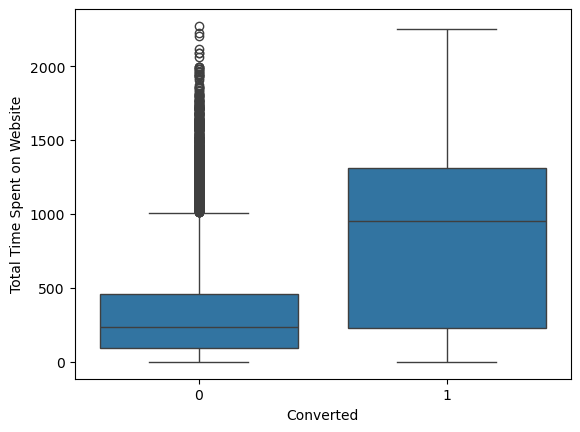

In [19]:
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=df)
plt.show()

**(B) Total Visits**

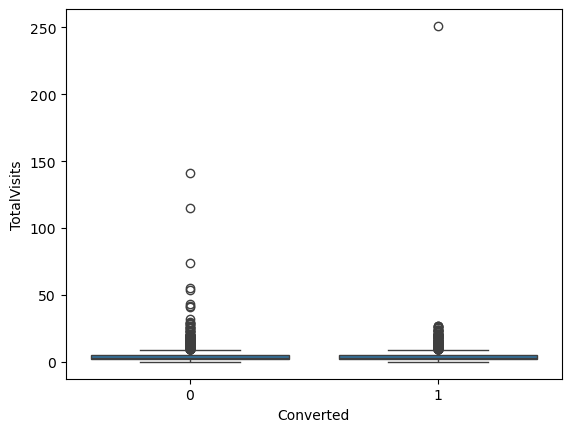

In [20]:
sns.boxplot(x='Converted', y='TotalVisits', data=df)
plt.show()

**Categorical Features Analysis**

**(A) Lead Source**

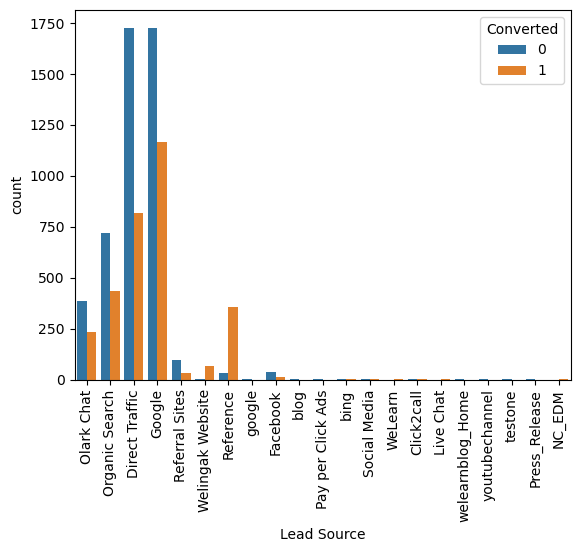

In [21]:
sns.countplot(x='Lead Source', hue='Converted', data=df)
plt.xticks(rotation=90)
plt.show()

**(B) Last Activity**

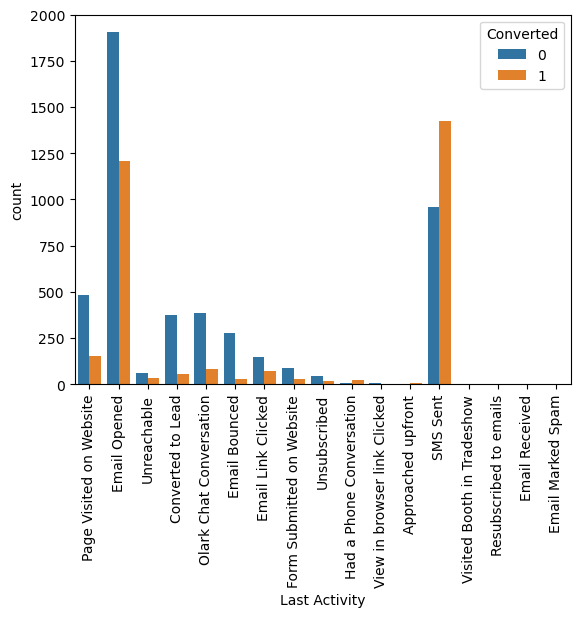

In [23]:
sns.countplot(x='Last Activity', hue='Converted', data=df)
plt.xticks(rotation=90)
plt.show()

**Missing Value Analysis**

In [26]:
(df.isnull().sum()/len(df))*100

Lead Origin                                      0.0
Lead Source                                      0.0
Do Not Email                                     0.0
Do Not Call                                      0.0
Converted                                        0.0
TotalVisits                                      0.0
Total Time Spent on Website                      0.0
Page Views Per Visit                             0.0
Last Activity                                    0.0
Country                                          0.0
Specialization                                   0.0
How did you hear about X Education               0.0
What is your current occupation                  0.0
What matters most to you in choosing a course    0.0
Search                                           0.0
Magazine                                         0.0
Newspaper Article                                0.0
X Education Forums                               0.0
Newspaper                                     

## Correlation Heatmap

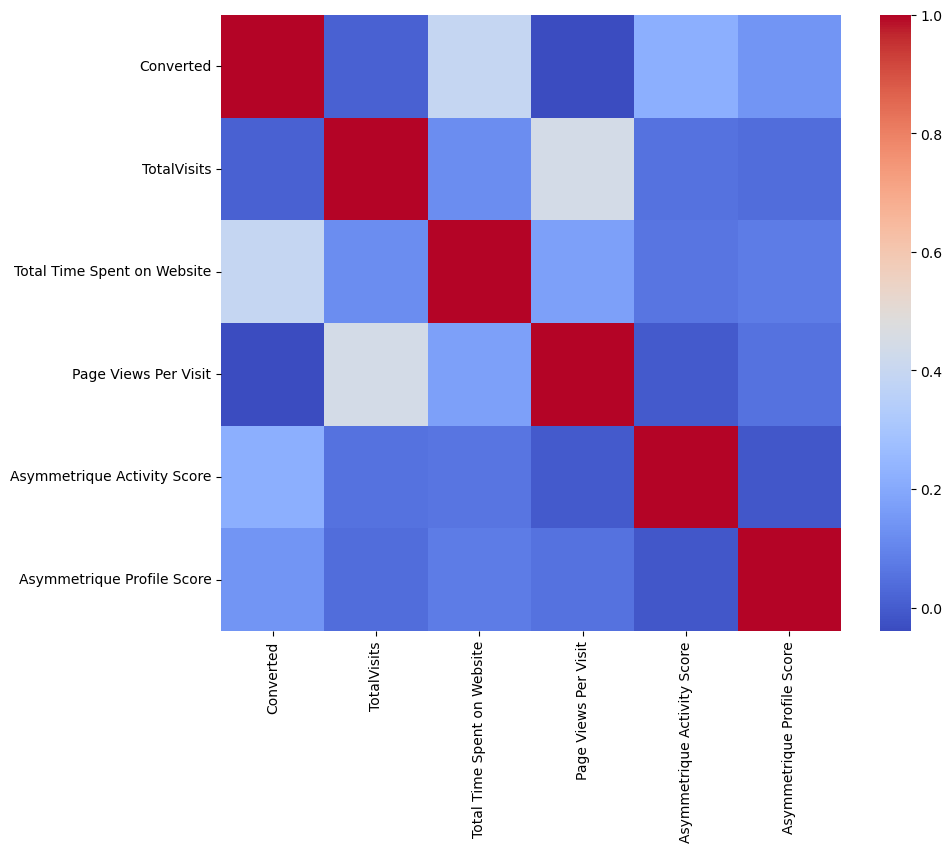

In [29]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.show()

# Outlier Analysis

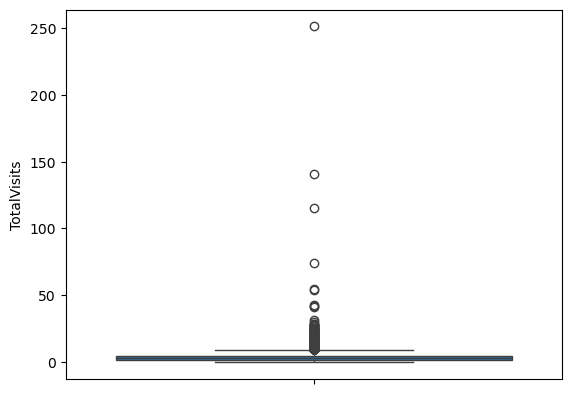

In [30]:
sns.boxplot(df['TotalVisits'])
plt.show()

# Derived Feature Analysis

In [32]:
df['Engagement_Score'] = df['Total Time Spent on Website'] * df['TotalVisits']

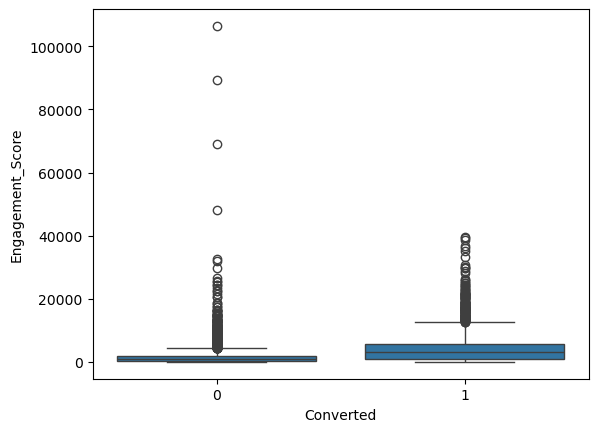

In [33]:
sns.boxplot(x='Converted', y='Engagement_Score', data=df)
plt.show()

# Conversion Rate by Category

In [34]:
df.groupby('Lead Source')['Converted'].mean().sort_values(ascending=False)

Lead Source
Live Chat            1.000000
WeLearn              1.000000
NC_EDM               1.000000
Welingak Website     0.971429
Reference            0.914948
Click2call           0.750000
Social Media         0.500000
Google               0.402903
Organic Search       0.377816
Olark Chat           0.376623
Direct Traffic       0.321667
Facebook             0.254902
Referral Sites       0.248000
bing                 0.166667
Pay per Click Ads    0.000000
Press_Release        0.000000
blog                 0.000000
google               0.000000
testone              0.000000
welearnblog_Home     0.000000
youtubechannel       0.000000
Name: Converted, dtype: float64

# Feature Engineering

In [35]:
df['Engagement_Score'] = df['Total Time Spent on Website'] * df['TotalVisits']
df['Engagement_Score']

0           0.0
1        3370.0
2        3064.0
3         305.0
4        2856.0
         ...   
9235    14760.0
9236      476.0
9237      398.0
9238     1497.0
9239     7674.0
Name: Engagement_Score, Length: 7869, dtype: float64

# Encoding

**1. Binary columns**

In [37]:
df['Do Not Email'] = df['Do Not Email'].map({'Yes':1, 'No':0})

**2. Categorical → Dummy**

In [38]:
df = pd.get_dummies(df, drop_first=True)
df

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score,Engagement_Score,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,0,0,0.0,0,0.00,15.0,15.0,0.0,False,False,...,False,False,True,False,False,False,False,False,False,False
1,0,0,5.0,674,2.50,15.0,15.0,3370.0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,1,2.0,1532,2.00,14.0,20.0,3064.0,True,False,...,False,False,False,False,False,False,False,False,False,False
3,0,0,1.0,305,1.00,13.0,17.0,305.0,True,False,...,False,False,True,False,False,False,False,False,False,False
4,0,1,2.0,1428,1.00,15.0,18.0,2856.0,True,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9235,1,1,8.0,1845,2.67,15.0,17.0,14760.0,True,False,...,False,False,False,False,False,False,False,False,False,False
9236,0,0,2.0,238,2.00,14.0,19.0,476.0,True,False,...,False,False,False,False,False,False,True,False,False,False
9237,1,0,2.0,199,2.00,13.0,20.0,398.0,True,False,...,False,False,False,False,False,False,True,False,False,False
9238,0,1,3.0,499,3.00,15.0,16.0,1497.0,True,False,...,False,False,False,False,False,False,True,False,False,False


In [39]:
print(df.isnull().sum().sum())

0


# Train-Test Split

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop('Converted', axis=1)
y = df['Converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Building

## Logistic Regression (MAIN MODEL)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

## Predictions

In [45]:
y_pred = model.predict(X_test)
y_pred
y_prob = model.predict_proba(X_test)[:,1]
y_prob

array([0.82811272, 0.19138534, 0.95043326, ..., 0.05516521, 0.79299932,
       0.00924879])

# ROC-AUC

In [46]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9259347475405366


# Evaluation

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test, y_prob))

0.8636171113934773
[[1330  121]
 [ 201  709]]
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1451
           1       0.85      0.78      0.81       910

    accuracy                           0.86      2361
   macro avg       0.86      0.85      0.85      2361
weighted avg       0.86      0.86      0.86      2361

0.9259347475405366


# Threshold Tuning

In [48]:
# Applying threshold for better conversion targeting
threshold = 0.7
y_pred_new = (y_prob > threshold).astype(int)
y_pred_new

array([1, 0, 1, ..., 0, 1, 0])

In [49]:
accuracy = accuracy_score(y_test, y_pred_new)
accuracy

0.8441338415925456

# Lead Score

In [50]:
lead_score = y_prob * 100
lead_score

array([82.81127165, 19.13853383, 95.04332633, ...,  5.51652125,
       79.29993151,  0.9248789 ])

# Important Features

In [51]:
import numpy as np

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

feature_importance.head()

,Feature,Importance
141,Tags_Will revert after reading the email,1.727637
177,Last Notable Activity_SMS Sent,1.189538
43,Last Activity_SMS Sent,1.149277
114,What is your current occupation_Working Profes...,0.899565
8,Lead Origin_Lead Add Form,0.832849


In [52]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance.head(10))

                                               Feature  Coefficient
141           Tags_Will revert after reading the email     1.727637
177                     Last Notable Activity_SMS Sent     1.189538
43                              Last Activity_SMS Sent     1.149277
114  What is your current occupation_Working Profes...     0.899565
8                            Lead Origin_Lead Add Form     0.832849
148                      Lead Quality_Low in Relevance     0.683755
124                            Tags_Closed by Horizzon     0.672095
20                               Lead Source_Reference     0.628401
132                                  Tags_Lost to EINS     0.328406
24                        Lead Source_Welingak Website     0.153030
